# Project : Predict GDP Growth rate of a country using Linear Regression

This jupyter notebook is used to create linear regression model to predict the GDP Growth rate of a country using the indicators available in the Database **World Development Indicators** from Databank website. 

The following tasks are performed in the project :

1. **Business understanding**
3. **Data understanding**
3. **Data Preparation**
    1. Data required for the model is obtained from Databank website in CSV Format
    2. Handling of missing values using pandas 
    3. Linear interpolation was used to fill missing values since the data being timeseries values
    4. Minmax Scaler used to scale the values
    5. Test train split performed by grouping on categorical values and splitting on years
4. **Linear regression** was performed on the test train split
5. **Model Evaluation**
    1. Evaluation metrics from sklearn were used
    2. *Shapley values* were plotted to interpret the model and find feature importance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

The selected data contains the following features:

**Year** 
> Starting from 2000 till 2021

**Country**
> Developed and developing nations were chosen  

**GDP (current US$)** 
>  Gross domestic product is the total income earned through the production of goods and services in an economic territory during an accounting period. It can be measured in three different ways: using either the expenditure approach, the income approach, or the production approach. This indicator is expressed in current prices, meaning no adjustment has been made to account for price changes over time. This indicator is expressed in United States dollars.

**GDP (annual % growth)**  
> Gross domestic product is the total income earned through the production of goods and services in an economic territory during an accounting period. It can be measured in three different ways: using either the expenditure approach, the income approach, or the production approach. This indicator denotes the percentage change over each previous year of the constant price (base year 2015) series in United States dollars.

**Inflation, consumer prices (annual % growth)**  
> Inflation as measured by the consumer price index reflects the annual percentage change in the cost to the average consumer of acquiring a basket of goods and services that may be fixed or changed at specified intervals, such as yearly. This indicator denotes the percentage change over each previous year of the constant price (base year 2015) series in United States dollars.

**Gross capital formation (% of GDP)**  
> Gross capital formation includes acquisitions less disposals of produced assets for purposes of fixed capital formation, inventories or valuables. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

**Life expectancy at birth, total (years)**  
> Life expectancy at birth indicates the number of years a newborn infant would live if prevailing patterns of mortality at the time of its birth were to stay the same throughout its life.

**Individuals using the Internet (% of population)**
> Internet users are individuals who have used the Internet (from any location) in the last 3 months. The Internet can be used via a computer, mobile phone, personal digital assistant, games machine, digital TV etc.

**Access to electricity (% of population)**
> Access to electricity is the percentage of population with access to electricity. Electrification data are collected from industry, national surveys and international sources.

**Exports of goods and services (% of GDP)**
> Exports of goods includes changes in the economic ownership of goods from residents of the compiling economy to non-residents, irrespective of physical movement of goods across national borders. Exports of services includes services provided by residents to non-residents. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

**Domestic credit to private sector by banks (% of GDP)**
> Domestic credit to private sector by banks refers to financial resources provided to the private sector by other depository corporations (deposit taking corporations except central banks), such as through loans, purchases of nonequity securities, and trade credits and other accounts receivable, that establish a claim for repayment. For some countries these claims include credit to public enterprises. This indicator is expressed as a percentage of Gross Domestic Product (GDP) which is the total income earned through the production of goods and services in an economic territory during an accounting period.

In [3]:
df_raw = pd.read_csv("C:/Users/u22z79/Documents/privat/Udacity/Data Science Nanodegree/Coding/Projectwork_introduction_to_datascience_and_supervisedML/sample4.csv")
df_raw.head()

,Time,Time Code,Country Name,Country Code,GDP (current US$) [NY.GDP.MKTP.CD],GDP growth (annual %) [NY.GDP.MKTP.KD.ZG],"Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]",Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS],"Life expectancy at birth, total (years) [SP.DYN.LE00.IN]",Individuals using the Internet (% of population) [IT.NET.USER.ZS],Access to electricity (% of population) [EG.ELC.ACCS.ZS],Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS],Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]
0,2000,YR2000,Germany,DEU,1.966981e+12,2.877246,1.4402683871974,23.9639660790924,77.926829,30.2163,100.0,29.6806532498145,..
1,2000,YR2000,India,IND,4.683955e+11,3.840991,4.00943591045191,25.677316683955,62.749000,0.527532,60.3,12.9972363113479,28.3395511575183
2,2000,YR2000,Australia,AUS,4.161678e+11,3.921503,4.45743514797223,26.2504640290701,79.234146,46.7561,100.0,19.3902280759468,87.5351786851453
3,2000,YR2000,Austria,AUT,1.961816e+11,3.189523,2.34486285357281,25.9400787116929,78.126829,33.7301,100.0,43.591091462861,..
4,2000,YR2000,Belgium,BEL,2.367925e+11,3.716705,2.54451776190909,23.7829613022103,77.721951,29.4317,100.0,72.5473951580567,..


In [4]:
df_raw.isna().sum()

Time                                                                         3
Time Code                                                                    5
Country Name                                                                 5
Country Code                                                                 5
GDP (current US$) [NY.GDP.MKTP.CD]                                           5
GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]                                    5
Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]                       5
Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]                          5
Life expectancy at birth, total (years) [SP.DYN.LE00.IN]                     5
Individuals using the Internet (% of population) [IT.NET.USER.ZS]            5
Access to electricity (% of population) [EG.ELC.ACCS.ZS]                     5
Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]                    5
Domestic credit to private sector by banks (% of GDP

In [5]:
df_raw[df_raw.isna().any(axis=1)]

,Time,Time Code,Country Name,Country Code,GDP (current US$) [NY.GDP.MKTP.CD],GDP growth (annual %) [NY.GDP.MKTP.KD.ZG],"Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]",Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS],"Life expectancy at birth, total (years) [SP.DYN.LE00.IN]",Individuals using the Internet (% of population) [IT.NET.USER.ZS],Access to electricity (% of population) [EG.ELC.ACCS.ZS],Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS],Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]
792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
795,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
796,Last Updated: 10/07/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_raw.dtypes

Time                                                                          object
Time Code                                                                     object
Country Name                                                                  object
Country Code                                                                  object
GDP (current US$) [NY.GDP.MKTP.CD]                                           float64
GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]                                    float64
Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]                        object
Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]                           object
Life expectancy at birth, total (years) [SP.DYN.LE00.IN]                     float64
Individuals using the Internet (% of population) [IT.NET.USER.ZS]             object
Access to electricity (% of population) [EG.ELC.ACCS.ZS]                     float64
Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]        

In [7]:
# Clean missing values 
# NaN values were dropped
df = df_raw.dropna()

In [8]:
#Shape before dropping values
df_raw.shape

(797, 13)

In [9]:
#Shape after dropping values
df.shape

(792, 13)

In [10]:
#Additionally there were values with .. (double dots). These values are empty so were replaced with NaN
df = df.replace("..", pd.NA)

**Time code and Country code** categorical Columns are either redundant or not required for the model. Subsequently these columns were dropped from the original dataset. One more thing carried out in the upcoming code block was to convert the numerical columns to float. In the original dataset, they were interpredted as strings. 

In [11]:
# Keeping only the relevant columns needed for the model
columns_to_keep = ['Country Name', 'Time', 
                   'GDP (current US$) [NY.GDP.MKTP.CD]',
                   'GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]',
                   'Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]',
                   'Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]',
                   'Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]',
                   'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]',
                   'Individuals using the Internet (% of population) [IT.NET.USER.ZS]',
                   'Access to electricity (% of population) [EG.ELC.ACCS.ZS]',
                   'Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]']

df = df[columns_to_keep]

# Renaming columns for my convenience
df = df.rename(columns={
    'Country Name':'Country',
    'Time':'Year',
    'GDP (current US$) [NY.GDP.MKTP.CD]':'GDP (current US$)',
    'Domestic credit to private sector by banks (% of GDP) [FD.AST.PRVT.GD.ZS]':'Domestic credit to private sector by banks (% of GDP)',
    'GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]':'GDP growth (annual %)',
    'Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]':'Inflation, consumer prices (annual %)',
    'Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]':'Gross capital formation (% of GDP)',
    'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]':'Life expectancy at birth, total (years)',
    'Individuals using the Internet (% of population) [IT.NET.USER.ZS]':'Individuals using the Internet (% of population)',
    'Access to electricity (% of population) [EG.ELC.ACCS.ZS]':'Access to electricity (% of population)',
    'Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]':'Exports of goods and services (% of GDP)'
})

# Column Year is set as integer
df['Year'] = df['Year'].astype(int)
df['Domestic credit to private sector by banks (% of GDP)'] = df['Domestic credit to private sector by banks (% of GDP)'].apply(pd.to_numeric, errors='coerce')
df['GDP growth (annual %)'] = df['GDP growth (annual %)'].apply(pd.to_numeric, errors='coerce')
df['Inflation, consumer prices (annual %)'] = df['Inflation, consumer prices (annual %)'].apply(pd.to_numeric, errors='coerce')
df['Gross capital formation (% of GDP)'] = df['Gross capital formation (% of GDP)'].apply(pd.to_numeric, errors='coerce')
df['Individuals using the Internet (% of population)'] = df['Individuals using the Internet (% of population)'].apply(pd.to_numeric, errors='coerce')
df['Access to electricity (% of population)'] = df['Access to electricity (% of population)'].apply(pd.to_numeric, errors='coerce')
df['Exports of goods and services (% of GDP)'] = df['Exports of goods and services (% of GDP)'].apply(pd.to_numeric, errors='coerce')

# Sort by Country and Year
df = df.sort_values(by=['Country','Year']).reset_index(drop=True)

# Resulting dataset
df.head()

,Country,Year,GDP (current US$),GDP growth (annual %),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
0,Australia,2000,4.161678e+11,3.921503,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228
1,Australia,2001,3.796293e+11,2.025106,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326
2,Australia,2002,3.957887e+11,3.979586,91.217703,2.981575,24.407426,79.936585,NaN,100.0,20.726661
3,Australia,2003,4.677391e+11,3.090762,99.134711,2.732596,25.936985,80.239024,NaN,100.0,19.057213
4,Australia,2004,6.146600e+11,4.224285,102.611546,2.343255,27.063647,80.490244,NaN,100.0,17.162468


In [12]:
df.dtypes

Country                                                   object
Year                                                       int32
GDP (current US$)                                        float64
GDP growth (annual %)                                    float64
Domestic credit to private sector by banks (% of GDP)    float64
Inflation, consumer prices (annual %)                    float64
Gross capital formation (% of GDP)                       float64
Life expectancy at birth, total (years)                  float64
Individuals using the Internet (% of population)         float64
Access to electricity (% of population)                  float64
Exports of goods and services (% of GDP)                 float64
dtype: object

In [13]:
df.shape

(792, 11)

In [14]:
df[df.Country == "Australia"]

,Country,Year,GDP (current US$),GDP growth (annual %),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
0,Australia,2000,4.161678e+11,3.921503,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228
1,Australia,2001,3.796293e+11,2.025106,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326
2,Australia,2002,3.957887e+11,3.979586,91.217703,2.981575,24.407426,79.936585,NaN,100.0,20.726661
3,Australia,2003,4.677391e+11,3.090762,99.134711,2.732596,25.936985,80.239024,NaN,100.0,19.057213
4,Australia,2004,6.146600e+11,4.224285,102.611546,2.343255,27.063647,80.490244,NaN,100.0,17.162468
5,Australia,2005,6.956929e+11,3.154168,108.433078,2.691832,27.456826,80.841463,63.0000,100.0,18.224373
6,Australia,2006,7.484176e+11,2.755346,113.601510,3.555288,27.504814,81.041463,66.0000,100.0,19.853539
7,Australia,2007,8.550075e+11,3.773322,120.511803,2.327611,27.501990,81.292683,69.4500,100.0,20.183504
8,Australia,2008,1.056112e+12,3.586267,121.713420,4.350299,28.603315,81.395122,71.6700,100.0,20.148877
9,Australia,2009,9.287621e+11,1.892556,122.507455,1.771117,27.364340,81.543902,74.2500,100.0,23.010985


In [15]:
df.isna().sum()

Country                                                   0
Year                                                      0
GDP (current US$)                                         0
GDP growth (annual %)                                     0
Domestic credit to private sector by banks (% of GDP)    26
Inflation, consumer prices (annual %)                    41
Gross capital formation (% of GDP)                        1
Life expectancy at birth, total (years)                   0
Individuals using the Internet (% of population)          4
Access to electricity (% of population)                   0
Exports of goods and services (% of GDP)                  1
dtype: int64

In [16]:
# Set pandas to display all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

In [17]:
#List all the rows with NaN values
df[df.isna().any(axis=1)]

,Country,Year,GDP (current US$),GDP growth (annual %),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
2,Australia,2002,3.957887e+11,3.979586,91.217703,2.981575,24.407426,79.936585,NaN,100.0,20.726661
3,Australia,2003,4.677391e+11,3.090762,99.134711,2.732596,25.936985,80.239024,NaN,100.0,19.057213
4,Australia,2004,6.146600e+11,4.224285,102.611546,2.343255,27.063647,80.490244,NaN,100.0,17.162468
22,Austria,2000,1.961816e+11,3.189523,NaN,2.344863,25.940079,78.126829,33.730100,100.0,43.591091
44,Belgium,2000,2.367925e+11,3.716705,NaN,2.544518,23.782961,77.721951,29.431700,100.0,72.547395
132,Germany,2000,1.966981e+12,2.877246,NaN,1.440268,23.963966,77.926829,30.216300,100.0,29.680653
175,India,2021,3.167271e+12,9.689592,50.142158,5.131407,32.115822,67.282000,NaN,99.6,21.399158
198,Ireland,2000,1.002076e+11,9.403525,NaN,5.577633,24.507951,76.536585,17.850500,100.0,94.389458
242,Italy,2000,1.149661e+12,3.882099,NaN,2.537685,21.323610,79.778049,23.110900,100.0,25.561196
308,Luxembourg,2000,2.123018e+10,6.938130,NaN,3.150767,22.559144,77.873171,22.887300,100.0,147.644884


For the model fitting, the features were split into dependent and independent ones. According to the business requirement, we need to predict the GDP growth rate of a company based on the economic, social and infrastructure indicators. The target feature **GDP growth (annual %)** is assigned to y and the remaining features to X dataframe.

In [18]:
X = df.drop({'GDP growth (annual %)'},axis=1)
y = df['GDP growth (annual %)']

In [19]:
X.dtypes

Country                                                   object
Year                                                       int32
GDP (current US$)                                        float64
Domestic credit to private sector by banks (% of GDP)    float64
Inflation, consumer prices (annual %)                    float64
Gross capital formation (% of GDP)                       float64
Life expectancy at birth, total (years)                  float64
Individuals using the Internet (% of population)         float64
Access to electricity (% of population)                  float64
Exports of goods and services (% of GDP)                 float64
dtype: object

By observing the missing values in the above cells, instead of imputing with average, median or nearest neighbour values basic linear interpolation was used. The values before and after the missing values seem to linearly increase for the features **Individuals using the Internet (% of population)** , **Domestic credit to private sector by banks (% of GDP)** and **Inflation, consumer prices (annual %)**. Considering this assumption, linear interpolation seemed to be a better option. 

In [20]:
X_interpolated = X.interpolate(method='nearest',limit_direction='both',axis=0)

C:\Users\u22z79\AppData\Local\Temp\ipykernel_17504\3453653841.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  X_interpolated = X.interpolate(method='nearest',limit_direction='both',axis=0)


In [21]:
X_interpolated[X_interpolated.isnull().any(axis=1)]

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)


In [22]:
X_interpolated[X_interpolated.Country == "Australia"]

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
0,Australia,2000,4.161678e+11,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228
1,Australia,2001,3.796293e+11,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326
2,Australia,2002,3.957887e+11,91.217703,2.981575,24.407426,79.936585,52.6893,100.0,20.726661
3,Australia,2003,4.677391e+11,99.134711,2.732596,25.936985,80.239024,52.6893,100.0,19.057213
4,Australia,2004,6.146600e+11,102.611546,2.343255,27.063647,80.490244,63.0000,100.0,17.162468
5,Australia,2005,6.956929e+11,108.433078,2.691832,27.456826,80.841463,63.0000,100.0,18.224373
6,Australia,2006,7.484176e+11,113.601510,3.555288,27.504814,81.041463,66.0000,100.0,19.853539
7,Australia,2007,8.550075e+11,120.511803,2.327611,27.501990,81.292683,69.4500,100.0,20.183504
8,Australia,2008,1.056112e+12,121.713420,4.350299,28.603315,81.395122,71.6700,100.0,20.148877
9,Australia,2009,9.287621e+11,122.507455,1.771117,27.364340,81.543902,74.2500,100.0,23.010985


In [23]:
X_interpolated.isna().sum()

Country                                                  0
Year                                                     0
GDP (current US$)                                        0
Domestic credit to private sector by banks (% of GDP)    0
Inflation, consumer prices (annual %)                    0
Gross capital formation (% of GDP)                       0
Life expectancy at birth, total (years)                  0
Individuals using the Internet (% of population)         0
Access to electricity (% of population)                  0
Exports of goods and services (% of GDP)                 0
dtype: int64

In [24]:
y.isna().sum()

0

In [28]:
#combing the dataframes again for plotting purposes
new_df = pd.concat([X_interpolated,y],axis=1)

In [29]:
new_df.head()

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP),GDP growth (annual %)
0,Australia,2000,4.161678e+11,87.535179,4.457435,26.250464,79.234146,46.7561,100.0,19.390228,3.921503
1,Australia,2001,3.796293e+11,88.359079,4.407135,23.393064,79.634146,52.6893,100.0,22.152326,2.025106
2,Australia,2002,3.957887e+11,91.217703,2.981575,24.407426,79.936585,52.6893,100.0,20.726661,3.979586
3,Australia,2003,4.677391e+11,99.134711,2.732596,25.936985,80.239024,52.6893,100.0,19.057213,3.090762
4,Australia,2004,6.146600e+11,102.611546,2.343255,27.063647,80.490244,63.0000,100.0,17.162468,4.224285


In [27]:
def split_test_train_data(df):
    '''
    split_test_train_data(df)

    Splits a DataFrame containing economic indicators by country and year into training and testing datasets.

    Parameters:
    df (pd.DataFrame): A pandas DataFrame containing the following columns:
        - 'Country'
        - 'Year'
        - 'GDP (current US$)'
        - 'Domestic credit to private sector by banks (% of GDP)'
        - 'Inflation, consumer prices (annual %)'
        - 'Gross capital formation (% of GDP)'
        - 'Life expectancy at birth, total (years)'
        - 'Individuals using the Internet (% of population)'
        - 'Access to electricity (% of population)'
        - 'Exports of goods and services (% of GDP)'
        - 'GDP growth (annual %)' (target variable)

    The function splits the data such that:
        - Training data includes records with Year ≤ 2016
        - Testing data includes records with Year ≥ 2017

    Returns:
    tuple: A tuple containing the following:
        - X_train (pd.DataFrame): Features for training
        - X_test (pd.DataFrame): Features for testing
        - y_train (pd.Series): Target values for training
        - y_test (pd.Series): Target values for testing
    '''

    # Defining my feature columns and target column
    X_cols = [   'Country','Year','GDP (current US$)','Domestic credit to private sector by banks (% of GDP)','Inflation, consumer prices (annual %)','Gross capital formation (% of GDP)',
                'Life expectancy at birth, total (years)','Individuals using the Internet (% of population)','Access to electricity (% of population)',
                'Exports of goods and services (% of GDP)']
    target_col = 'GDP growth (annual %)'

    # Initializing empty dataframes 
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()

    # Loop over each country and split by year
    for country, group in df.groupby('Country'):
        train_part = group[group['Year'] <= 2016]
        test_part = group[group['Year'] >= 2017]
        train_df = pd.concat([train_df, train_part])
        test_df = pd.concat([test_df, test_part])

    X_train = train_df[X_cols]
    y_train = train_df[target_col]

    X_test = test_df[X_cols]
    y_test = test_df[target_col]

    return X_train,X_test,y_train,y_test

array([[<Axes: title={'center': 'GDP (current US$)'}>,
        <Axes: title={'center': 'Domestic credit to private sector by banks (% of GDP)'}>,
        <Axes: title={'center': 'Inflation, consumer prices (annual %)'}>],
       [<Axes: title={'center': 'Gross capital formation (% of GDP)'}>,
        <Axes: title={'center': 'Life expectancy at birth, total (years)'}>,
        <Axes: title={'center': 'Individuals using the Internet (% of population)'}>],
       [<Axes: title={'center': 'Access to electricity (% of population)'}>,
        <Axes: title={'center': 'Exports of goods and services (% of GDP)'}>,
        <Axes: title={'center': 'GDP growth (annual %)'}>]], dtype=object)

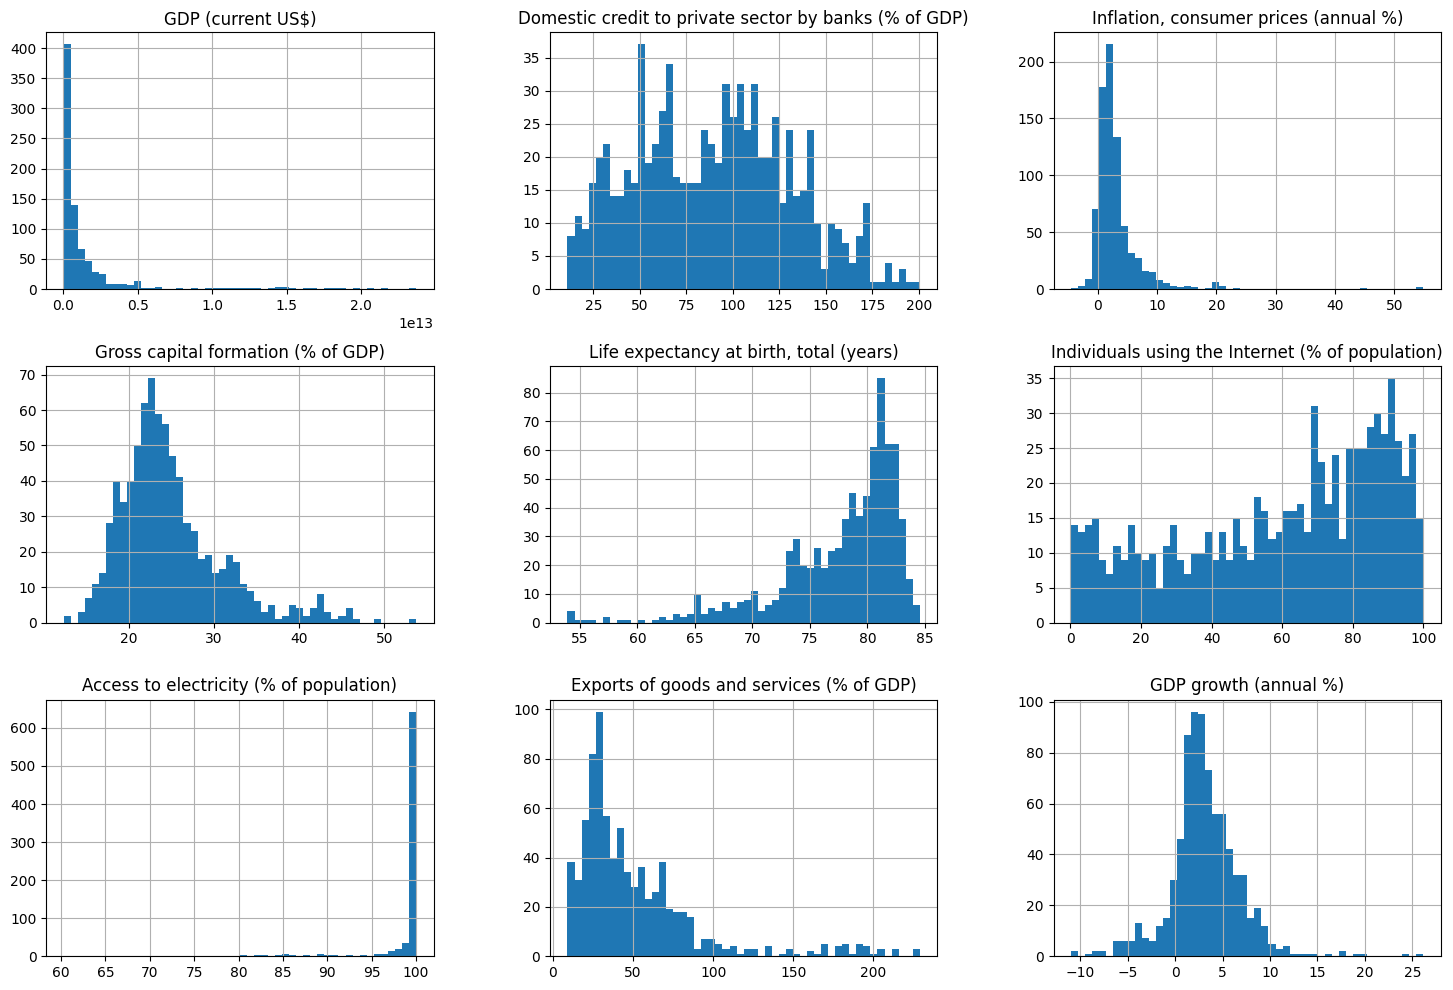

In [39]:
new_df.drop(columns=['Country', 'Year']).hist(bins=50, figsize=(18, 12))

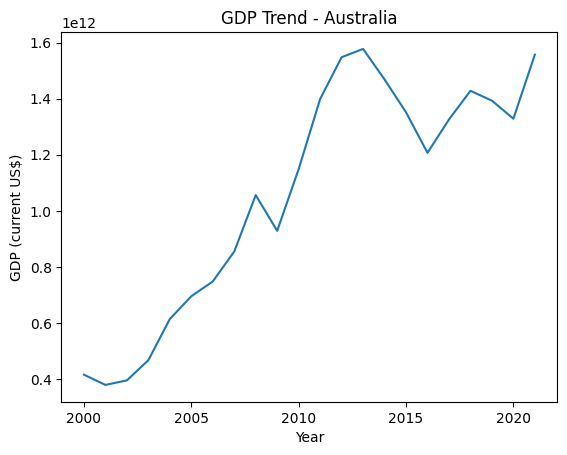

In [40]:
sns.lineplot(data=new_df[new_df["Country"]=="Australia"], x="Year", y="GDP (current US$)")
plt.title("GDP Trend - Australia")
plt.show()

In [41]:
'''
sns.lineplot(data=new_df, x="Year", y="GDP (current US$)", hue="Country")
plt.title("GDP Over Time by Country")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()
'''

'\nsns.lineplot(data=new_df, x="Year", y="GDP (current US$)", hue="Country")\nplt.title("GDP Over Time by Country")\nplt.legend(bbox_to_anchor=(1.05, 1))\nplt.show()\n'

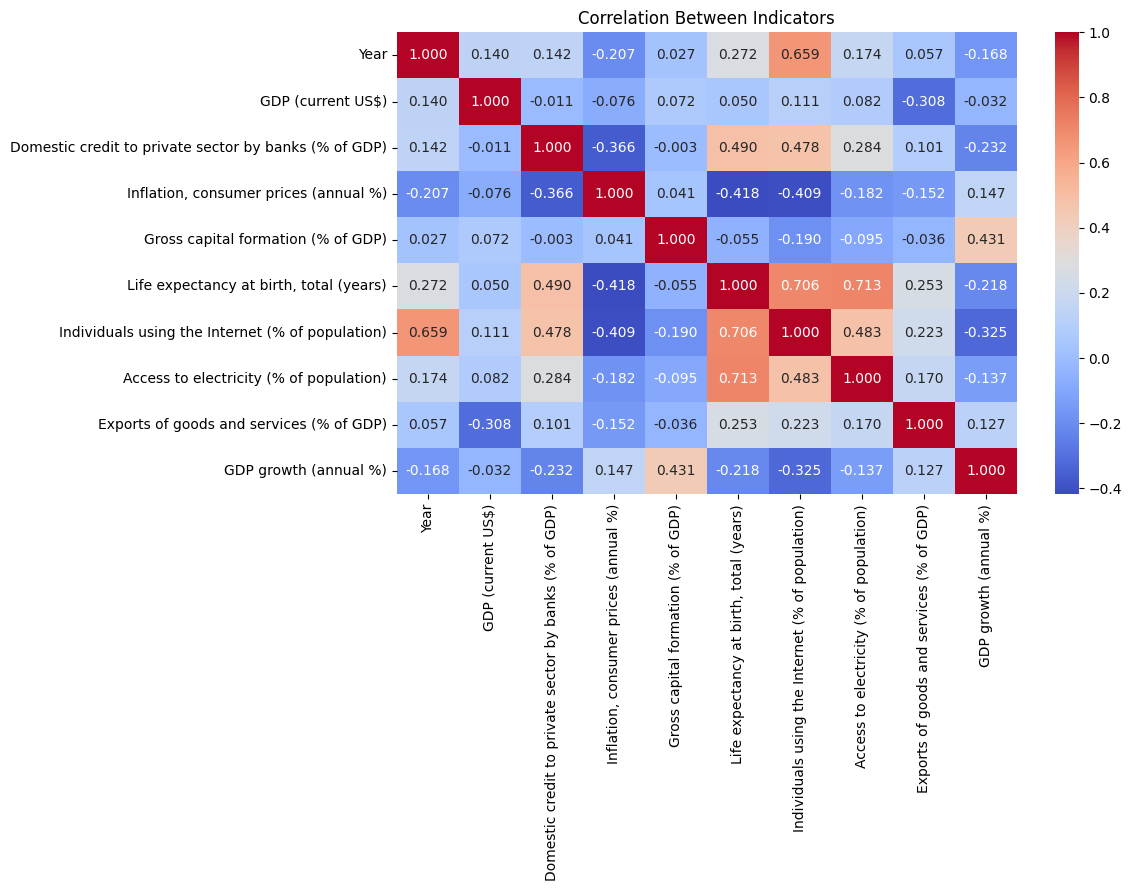

In [42]:
corr = new_df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Between Indicators")
plt.show()

In [43]:
# Print the correlation matrix sorted by linear correlation with the target
corr["GDP growth (annual %)"].sort_values(ascending=False)

GDP growth (annual %)                                    1.000000
Gross capital formation (% of GDP)                       0.430809
Inflation, consumer prices (annual %)                    0.147080
Exports of goods and services (% of GDP)                 0.126788
GDP (current US$)                                       -0.031664
Access to electricity (% of population)                 -0.137438
Year                                                    -0.168323
Life expectancy at birth, total (years)                 -0.218011
Domestic credit to private sector by banks (% of GDP)   -0.231920
Individuals using the Internet (% of population)        -0.325194
Name: GDP growth (annual %), dtype: float64

In [44]:
'''
# Assuming your DataFrame is named new_df
for country, group in new_df.groupby('Country'):
    print(f"\nCorrelation Matrix for {country}:\n")
    grouped_corr = group.drop(columns=['Country', 'Year']).corr()
    print(grouped_corr["GDP growth (annual %)"].sort_values(ascending=False))

    plt.figure(figsize=(10, 8))
    sns.heatmap(grouped_corr, annot=True, cmap='coolwarm')
    plt.title(f'Correlation Matrix Heatmap for {country}')
    plt.show()
'''

'\n# Assuming your DataFrame is named new_df\nfor country, group in new_df.groupby(\'Country\'):\n    print(f"\nCorrelation Matrix for {country}:\n")\n    grouped_corr = group.drop(columns=[\'Country\', \'Year\']).corr()\n    print(grouped_corr["GDP growth (annual %)"].sort_values(ascending=False))\n\n    plt.figure(figsize=(10, 8))\n    sns.heatmap(grouped_corr, annot=True, cmap=\'coolwarm\')\n    plt.title(f\'Correlation Matrix Heatmap for {country}\')\n    plt.show()\n'

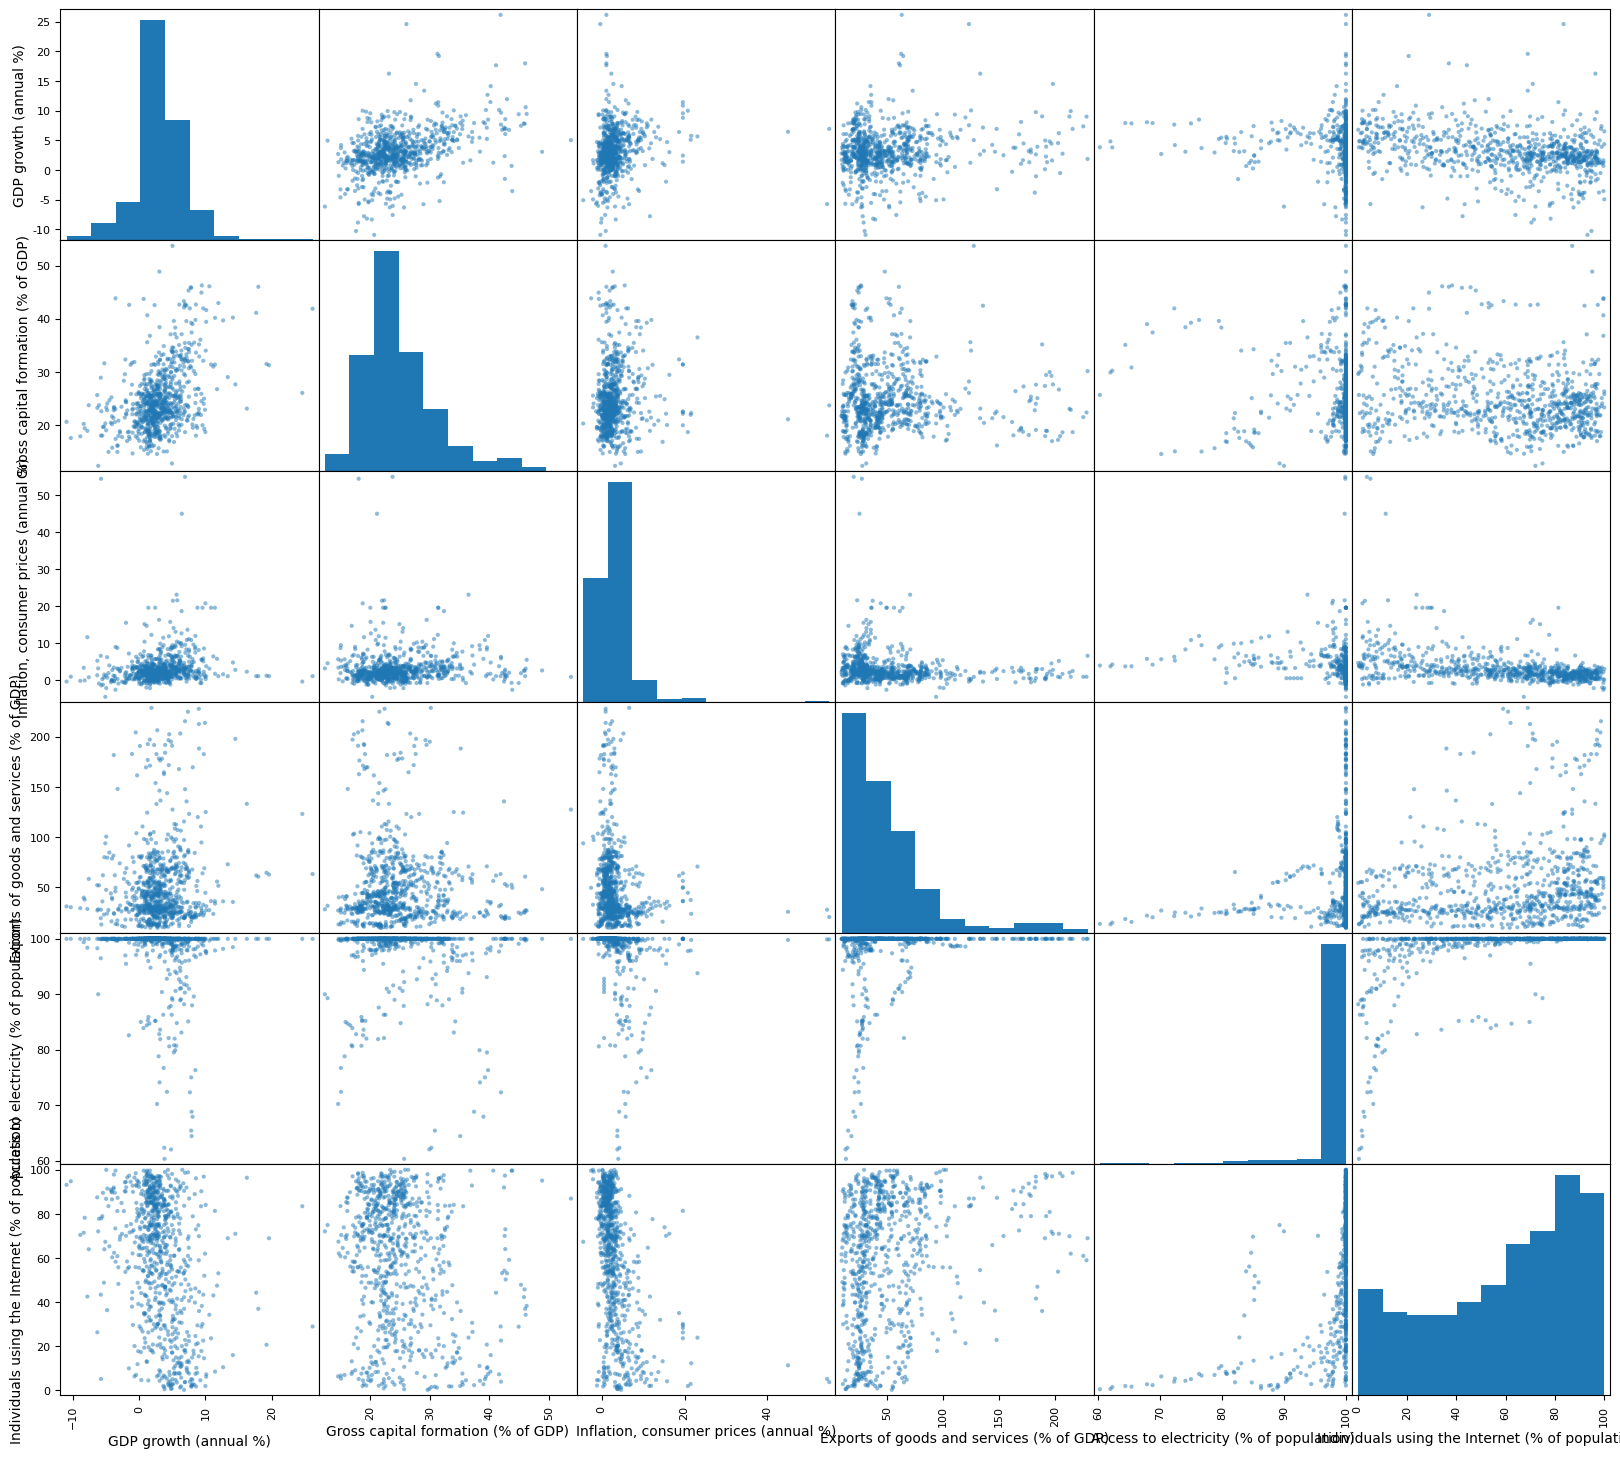

In [45]:
# Plot the most important feature pairs with a scatter plot
from pandas.plotting import scatter_matrix

features = ["GDP growth (annual %)", "Gross capital formation (% of GDP)", "Inflation, consumer prices (annual %)", "Exports of goods and services (% of GDP)","Access to electricity (% of population)","Individuals using the Internet (% of population)"]

scatter_matrix(new_df[features], figsize=(20, 18))
plt.show()

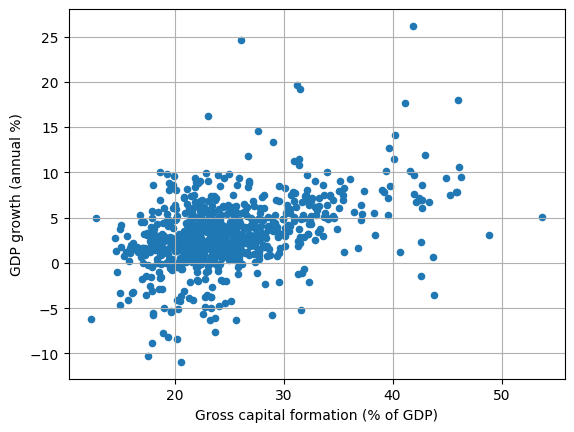

In [46]:
# Choose the most important feature and plot it against the target
new_df.plot(kind="scatter", x="Gross capital formation (% of GDP)", y="GDP growth (annual %)", grid=True)
plt.show()

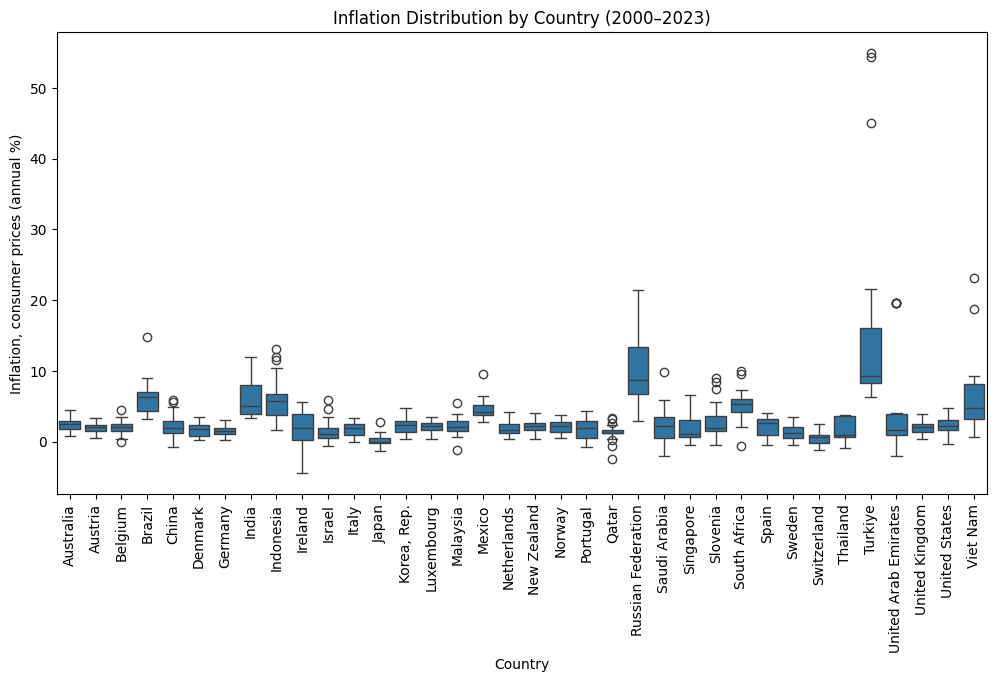

In [47]:
plt.figure(figsize=(12,6))
sns.boxplot(data=new_df, x="Country", y="Inflation, consumer prices (annual %)")
plt.xticks(rotation=90)
plt.title("Inflation Distribution by Country (2000–2023)")
plt.show()

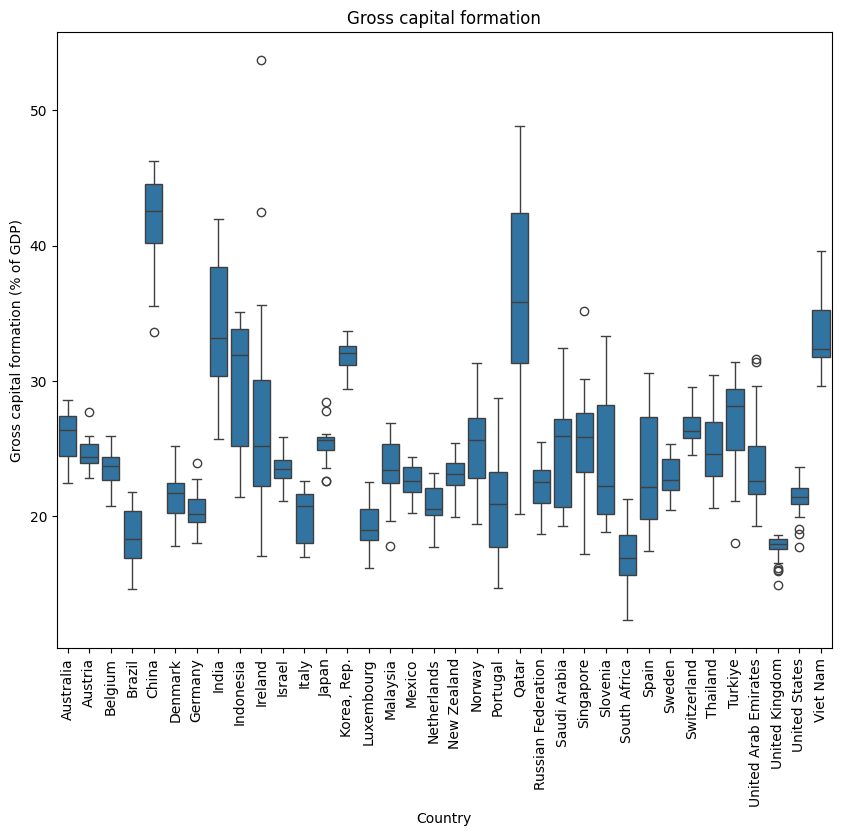

In [48]:
plt.figure(figsize=(10,8))
sns.boxplot(data=new_df, x="Country", y="Gross capital formation (% of GDP)")
plt.title("Gross capital formation")
plt.xticks(rotation=90)
plt.show()

In [49]:
variables = [
                "GDP growth (annual %)", 
                "Gross capital formation (% of GDP)", 
                "Inflation, consumer prices (annual %)", 
                "Exports of goods and services (% of GDP)"
]

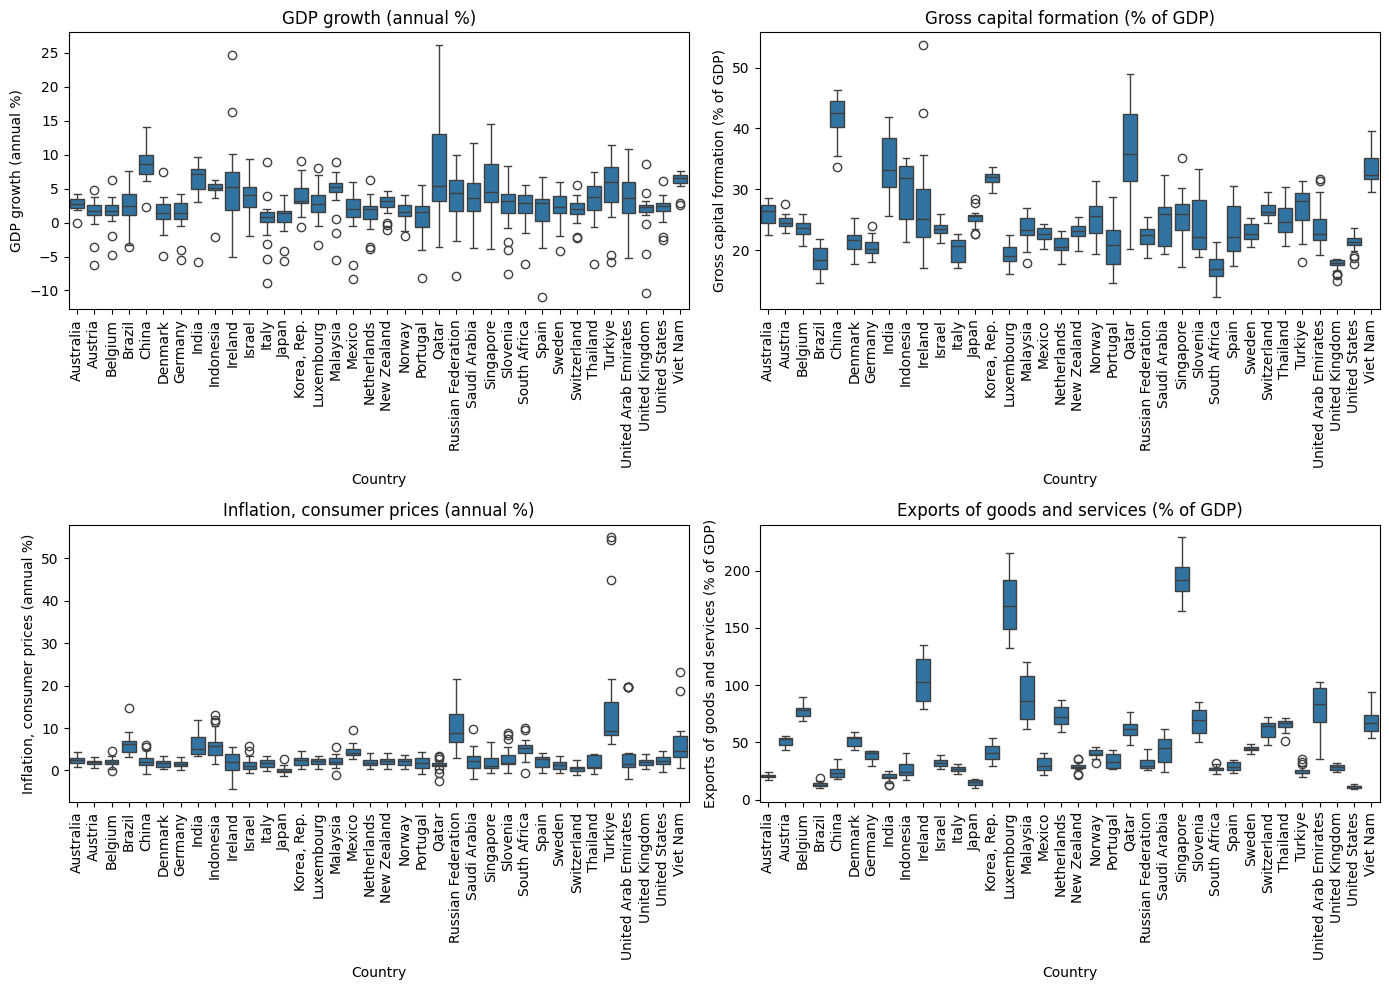

In [50]:
plt.figure(figsize=(14,10))

for i, var in enumerate(variables, 1):
    plt.subplot(2, 2, i)  # 2x2 grid
    sns.boxplot(data=new_df, x='Country', y=var)
    plt.title(var)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [51]:
#X_train.head()

In [52]:
'''
# Get list of categorical variables
s = (X_train.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables:")
print(object_cols)
'''

'\n# Get list of categorical variables\ns = (X_train.dtypes == \'object\')\nobject_cols = list(s[s].index)\n\nprint("Categorical variables:")\nprint(object_cols)\n'

In [53]:
#X_train.head()

In [54]:
'''
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[object_cols]),columns=OH_encoder.get_feature_names_out(object_cols),index=X_train.index)
OH_cols_test = pd.DataFrame(OH_encoder.transform(X_test[object_cols]),columns=OH_encoder.get_feature_names_out(object_cols),index=X_test.index)

# One-hot encoding removed index; put it back
#OH_cols_train.index = X_train.index
#OH_cols_test.index = X_test.index

# Remove categorical columns (will replace with one-hot encoding)
num_X_train = X_train.drop(object_cols, axis=1)
num_X_test = X_test.drop(object_cols, axis=1)

# Add one-hot encoded columns to numerical features
OH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
OH_X_test = pd.concat([num_X_test, OH_cols_test], axis=1)

# Ensure all columns have string type
OH_X_train.columns = OH_X_train.columns.astype(str)
OH_X_test.columns = OH_X_test.columns.astype(str)
'''

"\nfrom sklearn.preprocessing import OneHotEncoder\nOH_encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)\nOH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[object_cols]),columns=OH_encoder.get_feature_names_out(object_cols),index=X_train.index)\nOH_cols_test = pd.DataFrame(OH_encoder.transform(X_test[object_cols]),columns=OH_encoder.get_feature_names_out(object_cols),index=X_test.index)\n\n# One-hot encoding removed index; put it back\n#OH_cols_train.index = X_train.index\n#OH_cols_test.index = X_test.index\n\n# Remove categorical columns (will replace with one-hot encoding)\nnum_X_train = X_train.drop(object_cols, axis=1)\nnum_X_test = X_test.drop(object_cols, axis=1)\n\n# Add one-hot encoded columns to numerical features\nOH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)\nOH_X_test = pd.concat([num_X_test, OH_cols_test], axis=1)\n\n# Ensure all columns have string type\nOH_X_train.columns = OH_X_train.columns.astype(str)\nOH_X_test.columns = 

In [55]:
#OH_X_train.head()

In [56]:
#OH_X_test.head()

In [57]:
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_train.drop(['Year','Country'],axis=1)),columns = X_train.drop(['Year','Country'],axis=1).columns)
X_scaled = pd.concat([X_train[['Year','Country']],X_scaled],axis=1)
'''

"\nfrom sklearn.preprocessing import StandardScaler\n\nscaler = StandardScaler()\nX_scaled = pd.DataFrame(scaler.fit_transform(X_train.drop(['Year','Country'],axis=1)),columns = X_train.drop(['Year','Country'],axis=1).columns)\nX_scaled = pd.concat([X_train[['Year','Country']],X_scaled],axis=1)\n"

In [58]:
#X_scaled[X_scaled.Country.isin({"Australia","Germany"})]

In [59]:
from sklearn.preprocessing import MinMaxScaler

# List of features to scale (excluding 'Year' and 'Country')
features_to_scale = [
    'GDP (current US$)',
    'Domestic credit to private sector by banks (% of GDP)',
    'Inflation, consumer prices (annual %)',
    'Gross capital formation (% of GDP)',
    'Life expectancy at birth, total (years)',
    'Individuals using the Internet (% of population)',
    'Access to electricity (% of population)',
    'Exports of goods and services (% of GDP)'
]

# Create a copy of the DataFrame for scaled values
X_scaled = new_X.copy()

# Apply MinMaxScaler per country
for country in new_X['Country'].unique():
    mask = new_X['Country'] == country
    scaler = MinMaxScaler()
    X_scaled.loc[mask, features_to_scale] = scaler.fit_transform(new_X.loc[mask, features_to_scale])


In [60]:
X_scaled[X_scaled.Country.isin({"United States","China","India"})]

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
88,China,2000,0.000000,0.120592,0.162197,0.000000,0.000000,0.000000,0.000000,0.150299
89,China,2001,0.007732,0.104258,0.217973,0.149646,0.066392,0.012118,0.090909,0.115733
90,China,2002,0.015671,0.195876,0.000000,0.192766,0.127981,0.039561,0.151515,0.245898
91,China,2003,0.027103,0.296864,0.279332,0.458578,0.188197,0.062069,0.212121,0.489188
92,China,2004,0.044790,0.208790,0.684461,0.633165,0.246869,0.077501,0.303030,0.718557
93,China,2005,0.064425,0.125638,0.376792,0.517930,0.308286,0.094663,0.363636,0.876479
94,China,2006,0.092340,0.091403,0.357717,0.479285,0.363013,0.122722,0.454545,1.000000
95,China,2007,0.140200,0.048189,0.833492,0.521412,0.429062,0.199560,0.545455,0.964504
96,China,2008,0.202827,0.000000,1.000000,0.658988,0.436610,0.292156,0.636364,0.803428
97,China,2009,0.233587,0.278166,0.000572,0.893806,0.519643,0.380543,0.727273,0.359167


In [61]:
'''
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_minmax = pd.DataFrame(scaler.fit_transform(new_X.drop(['Year','Country'],axis=1)),columns = new_X.drop(['Year','Country'],axis=1).columns)
X_minmax = pd.concat([new_X[['Year','Country']],X_minmax],axis=1)
'''

"\nfrom sklearn.preprocessing import MinMaxScaler\n\nscaler = MinMaxScaler()\nX_minmax = pd.DataFrame(scaler.fit_transform(new_X.drop(['Year','Country'],axis=1)),columns = new_X.drop(['Year','Country'],axis=1).columns)\nX_minmax = pd.concat([new_X[['Year','Country']],X_minmax],axis=1)\n"

In [62]:
#X_minmax[X_minmax.Country.isin({"United States","China","India"})]

In [63]:
#X_train[X_train.Country.isin({"United States","China","India"})]

In [64]:
X_train,X_test,y_train,y_test = split_test_train_data(pd.concat([X_scaled,y],axis=1))

In [65]:
X_test.head()

,Country,Year,GDP (current US$),Domestic credit to private sector by banks (% of GDP),"Inflation, consumer prices (annual %)",Gross capital formation (% of GDP),"Life expectancy at birth, total (years)",Individuals using the Internet (% of population),Access to electricity (% of population),Exports of goods and services (% of GDP)
17,Australia,2017,0.789944,0.963819,0.305147,0.283143,0.803239,0.792353,0.0,0.585112
18,Australia,2018,0.875311,0.952034,0.294831,0.359267,0.864427,0.861156,0.0,0.676216
19,Australia,2019,0.846012,0.883019,0.211565,0.156027,0.901620,0.933043,0.0,1.000000
20,Australia,2020,0.792309,0.992130,0.000000,0.000000,0.975405,0.954622,0.0,0.981001
21,Australia,2021,0.982975,0.927820,0.558645,0.082504,1.000000,1.000000,0.0,0.699451


In [66]:
y_train.head()

0    3.921503
1    2.025106
2    3.979586
3    3.090762
4    4.224285
Name: GDP growth (annual %), dtype: float64

In [67]:
# Train a linear regression model on the training set
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train.drop(['Year','Country'],axis=1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error


y_pred_train = linear_model.predict(X_train.drop(['Year','Country'],axis=1))
y_pred_test = linear_model.predict(X_test.drop(['Year','Country'],axis=1))

mse_train = mean_squared_error(y_pred_train,y_train)
mse_test = mean_squared_error(y_pred_test,y_test)

r2_train = r2_score(y_pred_train,y_train)
r2_test = r2_score(y_pred_test,y_test)

rmse_train = root_mean_squared_error(y_pred_train,y_train)
rmse_test = root_mean_squared_error(y_pred_test,y_test)

print("MSE Train: ", mse_train)
print("MSE Test: ", mse_test)
print("R2 Train: ", r2_train)
print("R2 Test: ", r2_test)
print("RMSE Train: ", rmse_train)
print("RMSE Test: ", rmse_test)

MSE Train:  10.427518415519957
MSE Test:  15.916022636748679
R2 Train:  -2.7582153699207077
R2 Test:  -10.00802324292234
RMSE Train:  3.2291668299299676
RMSE Test:  3.9894890195047132


In [69]:
coefficients = linear_model.coef_
feature_names = X_train.drop(['Year','Country'],axis=1).columns
for feature,coef in zip(feature_names,coefficients):
    print(f"Coefficient for {feature} : {coef}")

Coefficient for GDP (current US$) : -1.616548532301582
Coefficient for Domestic credit to private sector by banks (% of GDP) : -1.994739927016585
Coefficient for Inflation, consumer prices (annual %) : -0.9369729641132324
Coefficient for Gross capital formation (% of GDP) : 2.9044790922878008
Coefficient for Life expectancy at birth, total (years) : 0.03856502878565715
Coefficient for Individuals using the Internet (% of population) : -1.98479058463017
Coefficient for Access to electricity (% of population) : 1.6195189027372414
Coefficient for Exports of goods and services (% of GDP) : 2.6058476294862594


c:\Users\u22z79\Documents\privat\Udacity\Data Science Nanodegree\Coding\udacity_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ExactExplainer explainer: 793it [00:10,  2.77it/s]                 


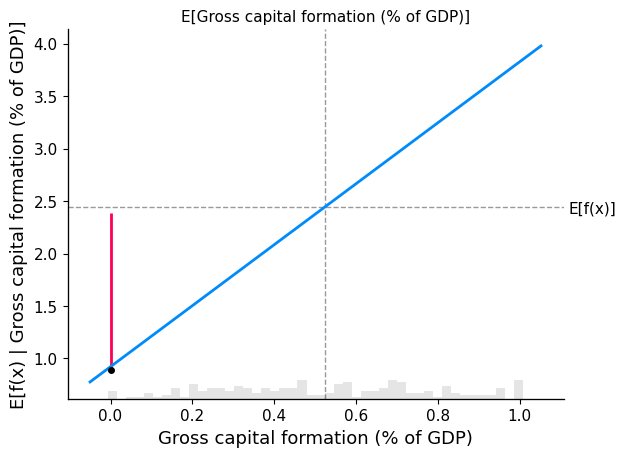

In [70]:
import shap

explainer = shap.Explainer(linear_model.predict, X_test.drop(['Year','Country'],axis=1))
shap_values = explainer(X_scaled.drop(['Year','Country'],axis=1))

# make a standard partial dependence plot
sample_ind = 20
shap.partial_dependence_plot(
    "Gross capital formation (% of GDP)",
    linear_model.predict,
    X_test.drop(['Year','Country'],axis=1),
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

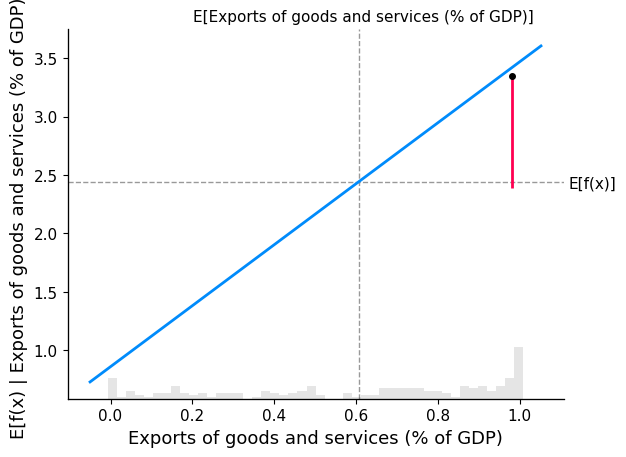

In [71]:
explainer = shap.Explainer(linear_model.predict, X_test.drop(['Year','Country'],axis=1))
shap_values = explainer(X_scaled.drop(['Year','Country'],axis=1))

# make a standard partial dependence plot
sample_ind = 20
shap.partial_dependence_plot(
    "Exports of goods and services (% of GDP)",
    linear_model.predict,
    X_test.drop(['Year','Country'],axis=1),
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

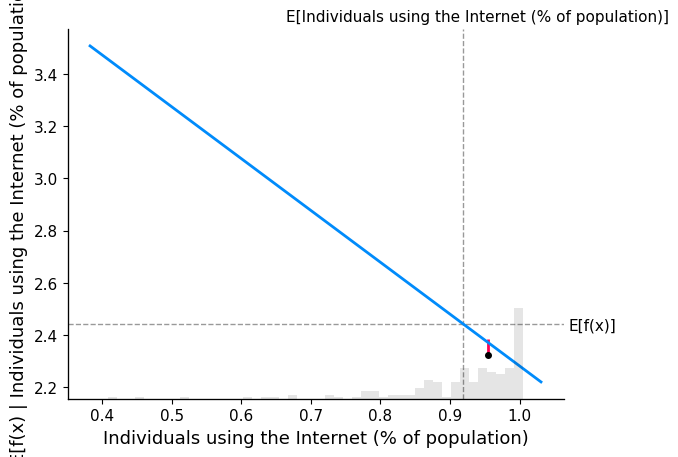

In [72]:
explainer = shap.Explainer(linear_model.predict, X_test.drop(['Year','Country'],axis=1))
shap_values = explainer(X_scaled.drop(['Year','Country'],axis=1))

# make a standard partial dependence plot
sample_ind = 20
shap.partial_dependence_plot(
    "Individuals using the Internet (% of population)",
    linear_model.predict,
    X_test.drop(['Year','Country'],axis=1),
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

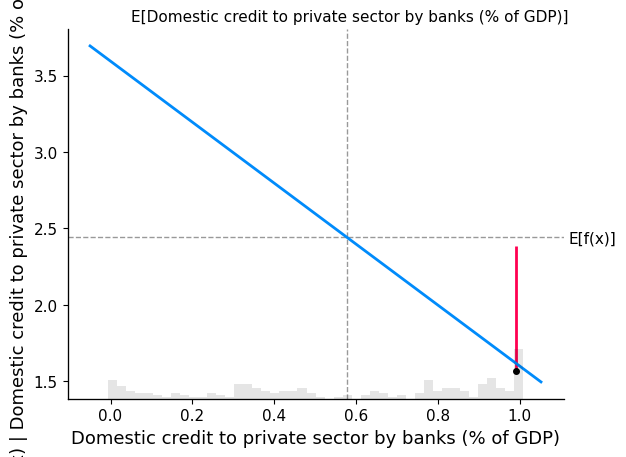

In [73]:
explainer = shap.Explainer(linear_model.predict, X_test.drop(['Year','Country'],axis=1))
shap_values = explainer(X_scaled.drop(['Year','Country'],axis=1))

# make a standard partial dependence plot
sample_ind = 20
shap.partial_dependence_plot(
    "Domestic credit to private sector by banks (% of GDP)",
    linear_model.predict,
    X_test.drop(['Year','Country'],axis=1),
    model_expected_value=True,
    feature_expected_value=True,
    ice=False,
    shap_values=shap_values[sample_ind : sample_ind + 1, :],
)

In [74]:
explainer

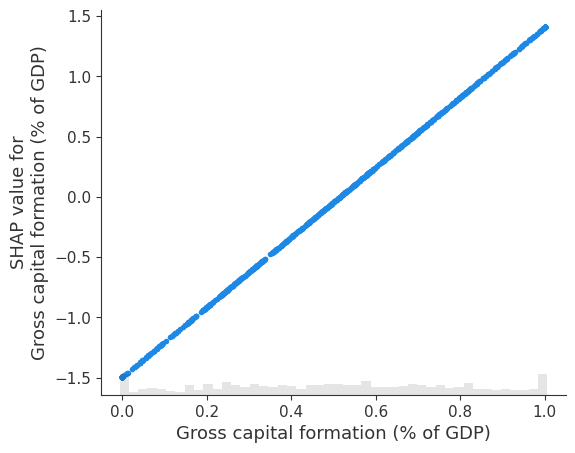

In [75]:
shap.plots.scatter(shap_values[:, "Gross capital formation (% of GDP)"])

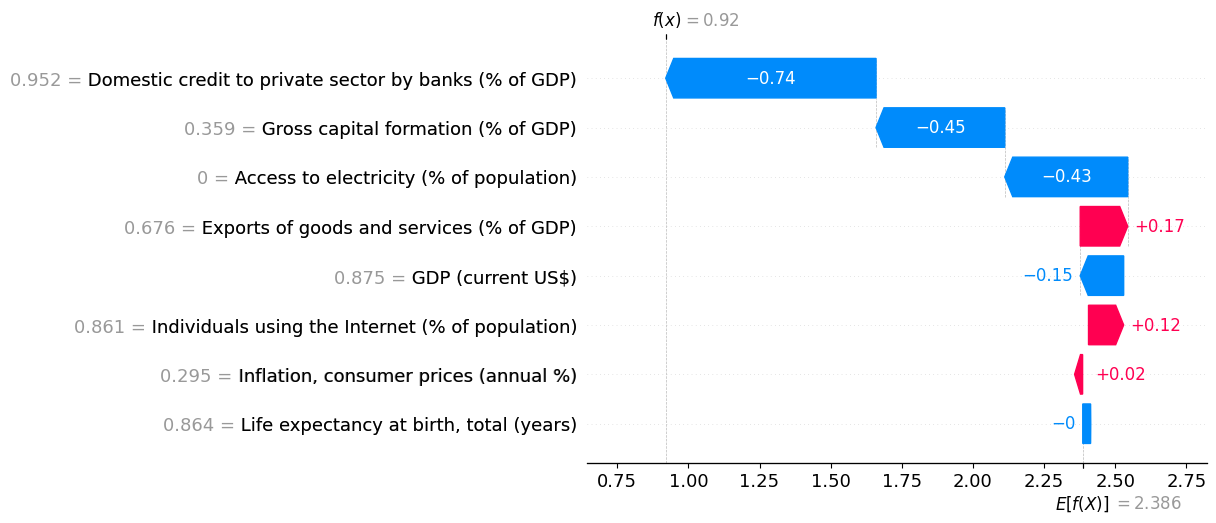

In [76]:
# the waterfall_plot shows how we get from shap_values.base_values to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values[18], max_display=14)

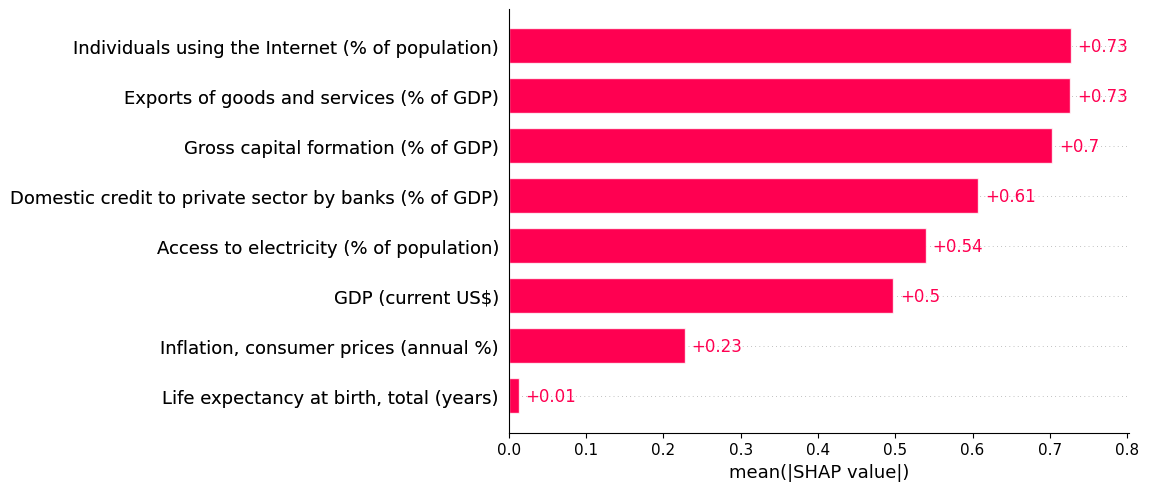

In [77]:
shap.plots.bar(shap_values)

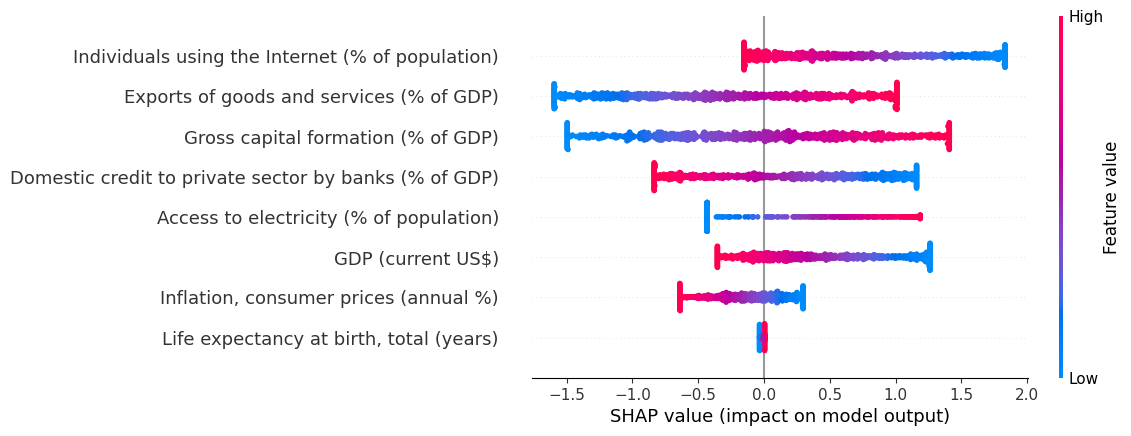

In [78]:
# 2. Beeswarm plot
shap.plots.beeswarm(shap_values)